# WaDi A2 - Notebook 7: Attack vs Fault Classifier
* **Input:** Feature matrix parquet from NB5, RF binary classifier from NB6
* **Scope:** Stage 2 of the cascaded anomaly classification system. Trains a supervised classifier to distinguish cyber attacks (label=1) from injected sensor faults (label=2). Evaluates in two modes: (1) clean evaluation on all test attack and fault rows, (2) end-to-end cascade evaluation using Stage 1 (NB6 RF) outputs.
* **Output:** Trained attack vs fault classifier, classification reports, confusion matrices, run log.

## Section 0.1 - Imports and Paths

In [24]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime, timezone
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve, 
    auc,
    precision_recall_curve, 
    average_precision_score,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# Paths
WORK_DIR     = Path("work")
PROJECT_DIR  = WORK_DIR / "wadi_A2"
DATA_DIR     = PROJECT_DIR / "data"
FEATURES_DIR = DATA_DIR / "features"
MODELS_DIR   = PROJECT_DIR / "models"
RESULTS_DIR  = PROJECT_DIR / "results" / "nb7"
REF_DIR      = DATA_DIR / "reference"
RUN_DIR      = REF_DIR / "pipeline_runs"

for p in [MODELS_DIR, RESULTS_DIR, RUN_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project:  ", PROJECT_DIR)
print("Features: ", FEATURES_DIR)
print("Models:   ", MODELS_DIR)
print("Results:  ", RESULTS_DIR)

Project:   work/wadi_A2
Features:  work/wadi_A2/data/features
Models:    work/wadi_A2/models
Results:   work/wadi_A2/results/nb7


## Section 0.2 - Helpers

In [2]:
class PipelineError(RuntimeError):
    pass

def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

def write_json(path: Path, obj: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, default=str))

def read_json(path: Path) -> dict:
    return json.loads(path.read_text())

def print_classification_report(y_true, y_pred, labels, target_names):
    report = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        digits=4,
    )
    print(report)
    return report

def plot_confusion_matrix(y_true, y_pred, labels, display_labels, title, path, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    cm_display = cm.astype(float) / cm.sum(axis=1, keepdims=True) if normalize else cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_display, display_labels=display_labels)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")
    return cm.tolist()

print("Helpers ready.")

Helpers ready.


## Section 0.3 - Configuration

In [3]:
DATASET_NAME = "WaDi.A2_19 Nov 2019"
RANDOM_SEED  = 42
RUN_ID       = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_utc")

# Stage 2 label definitions
S2_LABELS       = [1, 2]
S2_TARGET_NAMES = ["attack", "fault"]

# Random Forest config
RF_N_ESTIMATORS = 100
RF_RANDOM_STATE = RANDOM_SEED

# Stage 1 operating point to use for cascade evaluation
S1_THRESHOLD = 0.4   # balanced operating point from NB6

print(f"Dataset:      {DATASET_NAME}")
print(f"Random seed:  {RANDOM_SEED}")
print(f"Run ID:       {RUN_ID}")
print(f"S2 labels:    {dict(zip(S2_LABELS, S2_TARGET_NAMES))}")
print(f"S1 threshold: {S1_THRESHOLD}")

Dataset:      WaDi.A2_19 Nov 2019
Random seed:  42
Run ID:       20260330_152056_utc
S2 labels:    {1: 'attack', 2: 'fault'}
S1 threshold: 0.4


# Stage 1

Loads the feature matrix from NB5 and the trained binary RF classifier from NB6.
The feature matrix provides the full dataset with original three-class labels intact.
The NB6 model is used in Stage 5 for end-to-end cascade evaluation.

## 1.1 - Load Feature Matrix

In [4]:
feature_files = sorted(FEATURES_DIR.glob("wadi_features_*.parquet"))
if not feature_files:
    raise PipelineError(f"No feature matrix found in {FEATURES_DIR}")

features_path = feature_files[-1]
print(f"Loading: {features_path}")

df = pd.read_parquet(features_path)
print(f"Shape:   {df.shape}")

print(f"\nLabel distribution:")
for label_val, label_name in [(0, "normal"), (1, "attack"), (2, "fault")]:
    n   = (df["label"] == label_val).sum()
    pct = n / len(df) * 100
    print(f"  {label_name:<8} ({label_val}): {n:>9,}  ({pct:.2f}%)")

print(f"\nSplit distribution:")
for split in ["train", "test"]:
    n = (df["split"] == split).sum()
    print(f"  {split:<6}: {n:>9,}")

Loading: work/wadi_A2/data/features/wadi_features_20260311_133617_utc.parquet
Shape:   (807029, 549)

Label distribution:
  normal   (0):   786,489  (97.45%)
  attack   (1):     9,977  (1.24%)
  fault    (2):    10,563  (1.31%)

Split distribution:
  train :   637,211
  test  :   169,818


## 1.2 Load Feature Columns and NB6 Model

In [5]:
# Load canonical feature column list
feature_cols_path = REF_DIR / "feature_cols.json"
if not feature_cols_path.exists():
    raise PipelineError(f"feature_cols.json not found at {feature_cols_path}")

feature_ref  = read_json(feature_cols_path)
FEATURE_COLS = feature_ref["feature_cols"]

print(f"FEATURE_COLS loaded: {len(FEATURE_COLS)} features")

# Load NB6 binary RF model
model_files = sorted(MODELS_DIR.glob("rf_binary_*.joblib"))
if not model_files:
    raise PipelineError(f"No binary RF model found in {MODELS_DIR}")

model_path = model_files[-1]
rf_stage1  = joblib.load(model_path)
print(f"Stage 1 model loaded: {model_path.name}")

FEATURE_COLS loaded: 546 features
Stage 1 model loaded: rf_binary_20260311_140600_utc.joblib


# Stage 2 - Prepare Training and Test Sets  

Filters the feature matrix to attack and fault rows only.
Normal rows are excluded, Stage 2 only sees rows that have already
been flagged as anomalies. Train and test sets follow the existing
split assignment from NB1.

## 2.1 - Filter and summarize code cell

In [6]:
# Filter to attack and fault rows only
df_s2 = df[df["label"].isin([1, 2])].copy()

print(f"Stage 2 dataset shape: {df_s2.shape}")
print(f"\nLabel distribution:")
for label_val, label_name in [(1, "attack"), (2, "fault")]:
    n   = (df_s2["label"] == label_val).sum()
    pct = n / len(df_s2) * 100
    print(f"  {label_name:<8} ({label_val}): {n:>9,}  ({pct:.2f}%)")

print(f"\nBy split:")
for split in ["train", "test"]:
    split_df = df_s2[df_s2["split"] == split]
    n_attack = (split_df["label"] == 1).sum()
    n_fault  = (split_df["label"] == 2).sum()
    print(f"  {split}:  attack={n_attack:,}  fault={n_fault:,}  total={len(split_df):,}")

Stage 2 dataset shape: (20540, 549)

Label distribution:
  attack   (1):     9,977  (48.57%)
  fault    (2):    10,563  (51.43%)

By split:
  train:  attack=7,986  fault=8,647  total=16,633
  test:  attack=1,991  fault=1,916  total=3,907


## 2.2 Assemble Train and Test Arrays

In [7]:
train_df = df_s2[df_s2["split"] == "train"]
test_df  = df_s2[df_s2["split"] == "test"]

X_train = train_df[FEATURE_COLS].values
y_train = train_df["label"].values

X_test  = test_df[FEATURE_COLS].values
y_test  = test_df["label"].values

print(f"Train: X={X_train.shape}  attack={(y_train==1).sum():,}  fault={(y_train==2).sum():,}")
print(f"Test:  X={X_test.shape}  attack={(y_test==1).sum():,}  fault={(y_test==2).sum():,}")

Train: X=(16633, 546)  attack=7,986  fault=8,647
Test:  X=(3907, 546)  attack=1,991  fault=1,916


# Stage 3 - Train Attack vs Fault Classifier  
Trains a Random Forest classifier to distinguish cyber attacks (label=1)
from injected sensor faults (label=2). Trains on attack and fault rows
from the train split only. Class balance is near 1:1 by design,
no class weighting required.

In [8]:
import time

print("Training Random Forest (attack vs fault)...")
print(f"  n_estimators={RF_N_ESTIMATORS}, random_state={RF_RANDOM_STATE}")
print(f"  Train: {len(X_train):,} rows, {len(FEATURE_COLS)} features\n")

t0 = time.time()
rf_s2 = RandomForestClassifier(
    n_estimators = RF_N_ESTIMATORS,
    random_state = RF_RANDOM_STATE,
    oob_score    = True,
    n_jobs       = -1,
)
rf_s2.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"Done. Elapsed: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"OOB score: {rf_s2.oob_score_:.4f}")

Training Random Forest (attack vs fault)...
  n_estimators=100, random_state=42
  Train: 16,633 rows, 546 features

Done. Elapsed: 3.5s (0.1 min)
OOB score: 0.9975


# Stage 4 - Clean Stage 2 Evaluation  
Evaluates the attack vs fault classifier on all test attack and fault rows
directly, independent of Stage 1 outputs. This measures the intrinsic
discriminative performance of the Stage 2 classifier, how well it can
distinguish attack from fault given that an anomaly has already been confirmed.

## 4.1 - Evaluate

Attack vs Fault Classifier — Clean Evaluation (all test anomalies)
              precision    recall  f1-score   support

      attack     0.9910    0.9950    0.9930      1991
       fault     0.9948    0.9906    0.9927      1916

    accuracy                         0.9928      3907
   macro avg     0.9929    0.9928    0.9928      3907
weighted avg     0.9928    0.9928    0.9928      3907



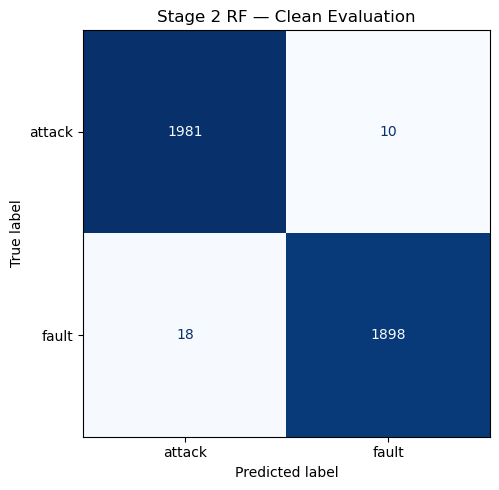

Saved: work/wadi_A2/results/nb7/s2_clean_confusion_matrix_20260330_152056_utc.png


In [9]:
y_pred_s2 = rf_s2.predict(X_test)

print("Attack vs Fault Classifier — Clean Evaluation (all test anomalies)")
print("=" * 60)
report_clean = print_classification_report(
    y_test, y_pred_s2,
    labels       = S2_LABELS,
    target_names = S2_TARGET_NAMES,
)
cm_clean = plot_confusion_matrix(
    y_test, y_pred_s2,
    labels         = S2_LABELS,
    display_labels = S2_TARGET_NAMES,
    title          = "Stage 2 RF — Clean Evaluation",
    path           = RESULTS_DIR / f"s2_clean_confusion_matrix_{RUN_ID}.png",
)

## 4.2 - Breakdown by Correct vs Incorrect Predictions

In [10]:
test_df_eval = test_df.copy()
test_df_eval["y_pred"] = y_pred_s2

correct   = (test_df_eval["label"] == test_df_eval["y_pred"]).sum()
incorrect = (test_df_eval["label"] != test_df_eval["y_pred"]).sum()

print(f"Correct predictions:   {correct:,}  ({correct/len(test_df_eval)*100:.2f}%)")
print(f"Incorrect predictions: {incorrect:,}  ({incorrect/len(test_df_eval)*100:.2f}%)")

print(f"\nError breakdown:")
attack_as_fault = ((test_df_eval["label"] == 1) & (test_df_eval["y_pred"] == 2)).sum()
fault_as_attack = ((test_df_eval["label"] == 2) & (test_df_eval["y_pred"] == 1)).sum()
print(f"  Attack predicted as fault: {attack_as_fault:,}")
print(f"  Fault predicted as attack: {fault_as_attack:,}")

Correct predictions:   3,879  (99.28%)
Incorrect predictions: 28  (0.72%)

Error breakdown:
  Attack predicted as fault: 10
  Fault predicted as attack: 18


# Stage 5 - End-to-End Cascade Evaluation  
Evaluates the full two-stage cascade system:
- Stage 1: NB6 binary RF flags rows as normal or anomaly (threshold=0.4)
- Stage 2: NB7 RF classifies flagged anomalies as attack or fault

Evaluation is performed on the full test split including normal rows.
This measures real-world system performance where Stage 1 errors
(missed anomalies and false positives) propagate into Stage 2.

## 5.2 - Run Stage 1 on Full Test Split

In [11]:
# Get full test split including normal rows
test_full = df[df["split"] == "test"].copy()

# Run Stage 1 binary RF
y_prob_s1 = rf_stage1.predict_proba(test_full[FEATURE_COLS].values)[:, 1]
test_full["s1_prob"]  = y_prob_s1
test_full["s1_pred"]  = (y_prob_s1 >= S1_THRESHOLD).astype(int)

print(f"Full test split: {len(test_full):,} rows")
print(f"\nStage 1 output at threshold={S1_THRESHOLD}:")
print(f"  Predicted normal:  {(test_full['s1_pred']==0).sum():,}")
print(f"  Predicted anomaly: {(test_full['s1_pred']==1).sum():,}")

print(f"\nStage 1 breakdown by true label:")
for label_val, label_name in [(0, "normal"), (1, "attack"), (2, "fault")]:
    subset    = test_full[test_full["label"] == label_val]
    n_flagged = (subset["s1_pred"] == 1).sum()
    pct       = n_flagged / len(subset) * 100
    print(f"  {label_name:<8} (n={len(subset):>6,}): "
          f"{n_flagged:>5,} flagged as anomaly  ({pct:.1f}%)")

Full test split: 169,818 rows

Stage 1 output at threshold=0.4:
  Predicted normal:  166,401
  Predicted anomaly: 3,417

Stage 1 breakdown by true label:
  normal   (n=165,911):   993 flagged as anomaly  (0.6%)
  attack   (n= 1,991): 1,965 flagged as anomaly  (98.7%)
  fault    (n= 1,916):   459 flagged as anomaly  (24.0%)


## 5.2 - Run Stage 2 on Flagged Rows

In [12]:
# Filter to rows flagged as anomaly by Stage 1
flagged = test_full[test_full["s1_pred"] == 1].copy()

print(f"Rows passed to Stage 2: {len(flagged):,}")
print(f"\nTrue label breakdown of flagged rows:")
for label_val, label_name in [(0, "normal"), (1, "attack"), (2, "fault")]:
    n   = (flagged["label"] == label_val).sum()
    pct = n / len(flagged) * 100
    print(f"  {label_name:<8}: {n:>5,}  ({pct:.1f}%)")

# Run Stage 2 on flagged rows
y_pred_s2_cascade = rf_s2.predict(flagged[FEATURE_COLS].values)
flagged["s2_pred"] = y_pred_s2_cascade

print(f"\nStage 2 predictions on flagged rows:")
print(f"  Predicted attack: {(y_pred_s2_cascade==1).sum():,}")
print(f"  Predicted fault:  {(y_pred_s2_cascade==2).sum():,}")

Rows passed to Stage 2: 3,417

True label breakdown of flagged rows:
  normal  :   993  (29.1%)
  attack  : 1,965  (57.5%)
  fault   :   459  (13.4%)

Stage 2 predictions on flagged rows:
  Predicted attack: 2,001
  Predicted fault:  1,416


## 5.3 - Evaluate Cascade on Attack and Fault Rows

End-to-End Cascade — Attack vs Fault (rows reaching Stage 2)
              precision    recall  f1-score   support

      attack     0.9959    0.9990    0.9975      1965
       fault     0.9956    0.9826    0.9890       459

    accuracy                         0.9959      2424
   macro avg     0.9958    0.9908    0.9932      2424
weighted avg     0.9959    0.9959    0.9959      2424



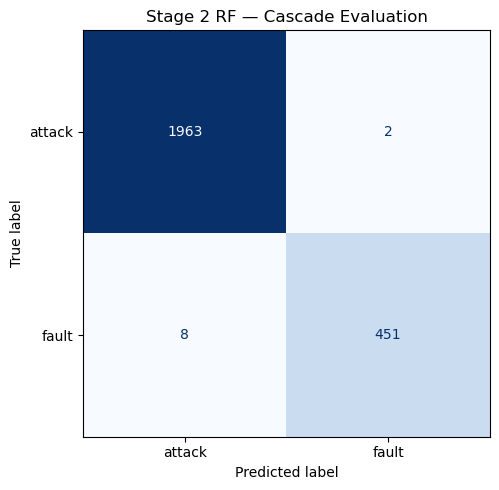

Saved: work/wadi_A2/results/nb7/s2_cascade_confusion_matrix_20260330_152056_utc.png


In [13]:
# Evaluate only on true anomaly rows that were flagged by Stage 1
flagged_anomalies = flagged[flagged["label"].isin([1, 2])]

print("End-to-End Cascade — Attack vs Fault (rows reaching Stage 2)")
print("=" * 60)
report_cascade = print_classification_report(
    flagged_anomalies["label"].values,
    flagged_anomalies["s2_pred"].values,
    labels       = S2_LABELS,
    target_names = S2_TARGET_NAMES,
)
cm_cascade = plot_confusion_matrix(
    flagged_anomalies["label"].values,
    flagged_anomalies["s2_pred"].values,
    labels         = S2_LABELS,
    display_labels = S2_TARGET_NAMES,
    title          = "Stage 2 RF — Cascade Evaluation",
    path           = RESULTS_DIR / f"s2_cascade_confusion_matrix_{RUN_ID}.png",
)

## 5.4 - Full System Summary

In [14]:
total_test     = len(test_full)
n_attack       = (test_full["label"] == 1).sum()
n_fault        = (test_full["label"] == 2).sum()
n_normal       = (test_full["label"] == 0).sum()

# Attacks correctly identified end-to-end
attack_flagged   = flagged[flagged["label"] == 1]
attacks_correct  = (attack_flagged["s2_pred"] == 1).sum()

# Faults correctly identified end-to-end
fault_flagged    = flagged[flagged["label"] == 2]
faults_correct   = (fault_flagged["s2_pred"] == 2).sum()

# False positives from Stage 1 that reach Stage 2
fp_reaching_s2   = (flagged["label"] == 0).sum()

print("Full Cascade System Summary")
print("=" * 60)
print(f"\nTest split composition:")
print(f"  Normal rows:  {n_normal:,}")
print(f"  Attack rows:  {n_attack:,}")
print(f"  Fault rows:   {n_fault:,}")
print(f"\nEnd-to-end performance:")
print(f"  Attacks correctly classified: {attacks_correct:,} / {n_attack:,}  "
      f"({attacks_correct/n_attack*100:.1f}%)")
print(f"  Faults correctly classified:  {faults_correct:,} / {n_fault:,}  "
      f"({faults_correct/n_fault*100:.1f}%)")
print(f"  Normal rows falsely flagged:  {fp_reaching_s2:,} / {n_normal:,}  "
      f"({fp_reaching_s2/n_normal*100:.1f}%)")

Full Cascade System Summary

Test split composition:
  Normal rows:  165,911
  Attack rows:  1,991
  Fault rows:   1,916

End-to-end performance:
  Attacks correctly classified: 1,963 / 1,991  (98.6%)
  Faults correctly classified:  451 / 1,916  (23.5%)
  Normal rows falsely flagged:  993 / 165,911  (0.6%)


# Stage 6 - Feature Importance  
Top features by importance for the attack vs fault classifier.
Compared against NB6 binary classifier importances to identify
which sensors are most discriminative for attack vs fault distinction
specifically, vs normal vs anomaly detection broadly.

Top 20 Features by Importance — Attack vs Fault Classifier
   1. 2A_AIT_004_PV__mean_60s                        0.0497
   2. 2A_AIT_004_PV                                  0.0483
   3. 1_AIT_003_PV                                   0.0406
   4. 1_AIT_004_PV__mean_60s                         0.0406
   5. 1_AIT_003_PV__min_60s                          0.0401
   6. 1_AIT_003_PV__mean_60s                         0.0391
   7. 2_FIC_501_SP                                   0.0321
   8. 1_AIT_005_PV__mean_60s                         0.0290
   9. 2B_AIT_004_PV__min_60s                         0.0278
  10. 2B_AIT_004_PV                                  0.0261
  11. 2_FIC_401_SP                                   0.0260
  12. 2_PIT_001_PV__mean_60s                         0.0233
  13. 2_FIC_601_SP                                   0.0214
  14. 2B_AIT_002_PV__std_60s                         0.0207
  15. 1_AIT_004_PV__max_60s                          0.0156
  16. 2_P_004_SPEED                      

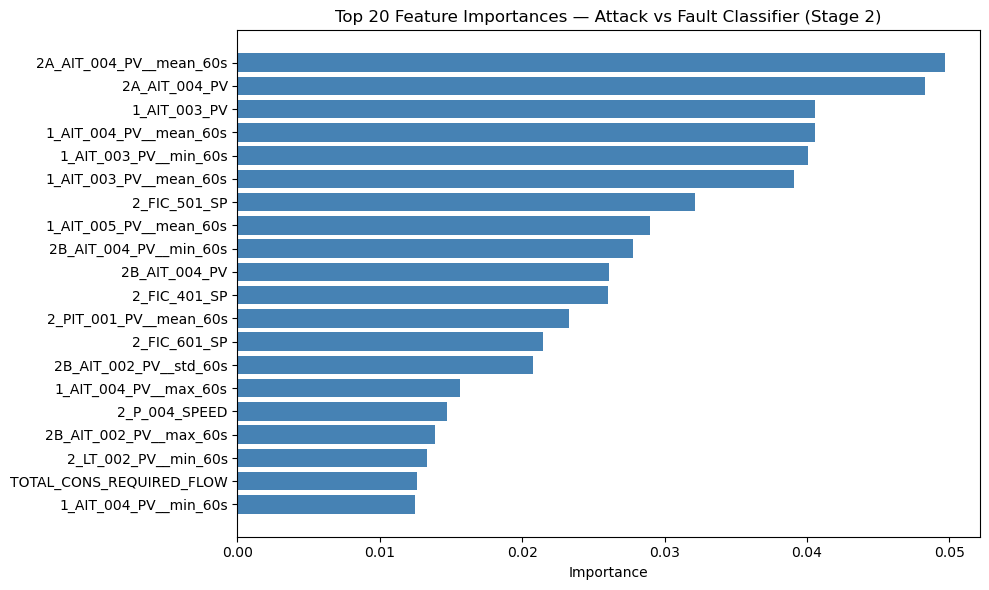

Saved: work/wadi_A2/results/nb7/s2_feature_importance_20260330_152056_utc.png


In [15]:
importances = rf_s2.feature_importances_
indices = np.argsort(importances)[::-1][:20]

print("Top 20 Features by Importance — Attack vs Fault Classifier")
print("=" * 60)
for rank, idx in enumerate(indices, 1):
    print(f"  {rank:>2}. {FEATURE_COLS[idx]:<45s}  {importances[idx]:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [FEATURE_COLS[i] for i in indices[::-1]],
    importances[indices[::-1]],
    color="steelblue"
)
ax.set_xlabel("Importance")
ax.set_title("Top 20 Feature Importances — Attack vs Fault Classifier (Stage 2)")
plt.tight_layout()
feat_imp_path = RESULTS_DIR / f"s2_feature_importance_{RUN_ID}.png"
plt.savefig(feat_imp_path, dpi=150)
plt.show()
print(f"Saved: {feat_imp_path}")

# Stage 7 - Artifacts  
Saves the trained Stage 2 model and writes the run log.

## 7.1 - Save Model

In [16]:
s2_model_path = MODELS_DIR / f"rf_attack_vs_fault_{RUN_ID}.joblib"
joblib.dump(rf_s2, s2_model_path)
print(f"Stage 2 model saved: {s2_model_path}")

Stage 2 model saved: work/wadi_A2/models/rf_attack_vs_fault_20260330_152056_utc.joblib


## 7.2 - Run Log

In [17]:
run_log = {
    "run_id":         RUN_ID,
    "created_at_utc": utc_now_iso(),
    "stage":          "Notebook 7 — Attack vs Fault Classifier",
    "dataset":        DATASET_NAME,
    "inputs": {
        "feature_matrix":  str(features_path),
        "feature_cols":    str(feature_cols_path),
        "s1_model":        str(model_path),
    },
    "outputs": {
        "s2_model": str(s2_model_path),
    },
    "configuration": {
        "n_estimators":  RF_N_ESTIMATORS,
        "random_state":  RF_RANDOM_STATE,
        "oob_score":     True,
        "s1_threshold":  S1_THRESHOLD,
        "train_rows":    int(X_train.shape[0]),
        "test_rows":     int(X_test.shape[0]),
        "n_features":    len(FEATURE_COLS),
    },
    "oob_score": round(float(rf_s2.oob_score_), 4),
    "clean_evaluation": {
        "total_rows":  int(X_test.shape[0]),
        "accuracy":    round(float((y_pred_s2 == y_test).mean()), 4),
        "attack_correct": int((y_pred_s2[y_test == 1] == 1).sum()),
        "fault_correct":  int((y_pred_s2[y_test == 2] == 2).sum()),
        "attack_as_fault": int(attack_as_fault),
        "fault_as_attack": int(fault_as_attack),
    },
    "cascade_evaluation": {
        "s1_threshold":           S1_THRESHOLD,
        "attacks_correct_e2e":    int(attacks_correct),
        "attacks_total":          int(n_attack),
        "faults_correct_e2e":     int(faults_correct),
        "faults_total":           int(n_fault),
        "normal_falsely_flagged": int(fp_reaching_s2),
        "normal_total":           int(n_normal),
    },
    "notes": [
        "Stage 2 trains on attack and fault rows only — normal rows excluded.",
        "Clean evaluation: all test attack and fault rows regardless of Stage 1 output.",
        "Cascade evaluation: only rows flagged by Stage 1 at balanced threshold (0.4).",
        "Fault end-to-end performance limited by Stage 1 fault recall (~24%) not Stage 2.",
        "Stage 2 intrinsic performance: 99.28% accuracy on confirmed anomaly rows.",
    ],
}

run_log_path = RUN_DIR / f"run_{RUN_ID}.json"
write_json(run_log_path, run_log)
print(f"Run log written: {run_log_path}")

Run log written: work/wadi_A2/data/reference/pipeline_runs/run_20260330_152056_utc.json


## 7.3 - Proposal Visualizations  
Figures for the research proposal.  

### End-to-End Confusion Matrix

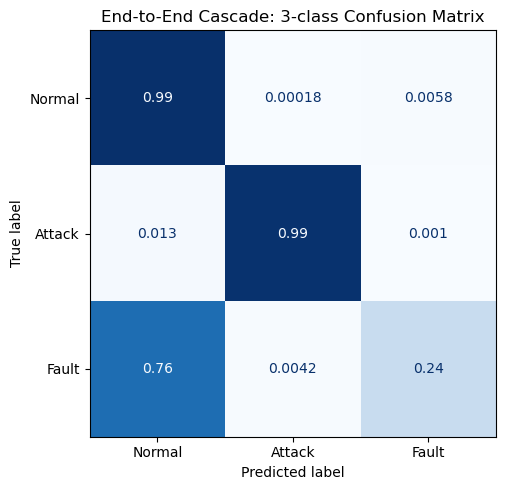

Saved: work/wadi_A2/results/nb7/proposal_cm_e2e_20260330_152056_utc.png


PosixPath('work/wadi_A2/results/nb7/proposal_cm_e2e_final.png')

In [27]:
# Merge Stage 2 predictions back onto test_full
test_full["s2_pred"] = flagged["s2_pred"]

# Build end-to-end prediction column
test_full["y_pred_e2e"] = np.where(
    test_full["s1_pred"] == 0,
    0,
    test_full["s2_pred"].fillna(0).astype(int)
)

# Plot and save
plot_confusion_matrix(
    test_full["label"].values,
    test_full["y_pred_e2e"].values,
    labels = [0, 1, 2],
    display_labels = ["Normal", "Attack", "Fault"],
    title = "End-to-End Cascade: 3-class Confusion Matrix",
    path = RESULTS_DIR / f"proposal_cm_e2e_{RUN_ID}.png",
    normalize=True
)

import shutil
shutil.copy(
    RESULTS_DIR / f"proposal_cm_e2e_{RUN_ID}.png",
    RESULTS_DIR / "proposal_cm_e2e_final.png"
)

#### Analysis
The confusion matrix shows end-to-end cascade performance across all three classes on the full test split. Each row represents the true label; each column represents the predicted label. Values are normalized by true class so cell colors reflect the proportion of each class correctly or incorrectly classified, rather than raw counts (which would have been dominated by the normal/normal cell).

The diagonal cells show correct classification rates:
* normal = 0.99
* attack = 0.99
* fault = 0.24

The fault row is the key finding. 0.76 of true fault rows are predicted normal, meaning Stage 1 misses them entirely and they never reach Stage 2. This is the identified bottleneck in the cascade. Stage 2 correctly classifies faults that reach it.

The off-diagonal attack cells are near zero, confirming that the pipeline reliably distinguishes attacks from both normal operation and sensor faults.

### Feature Importance (Stage 1 vs Stage 2)

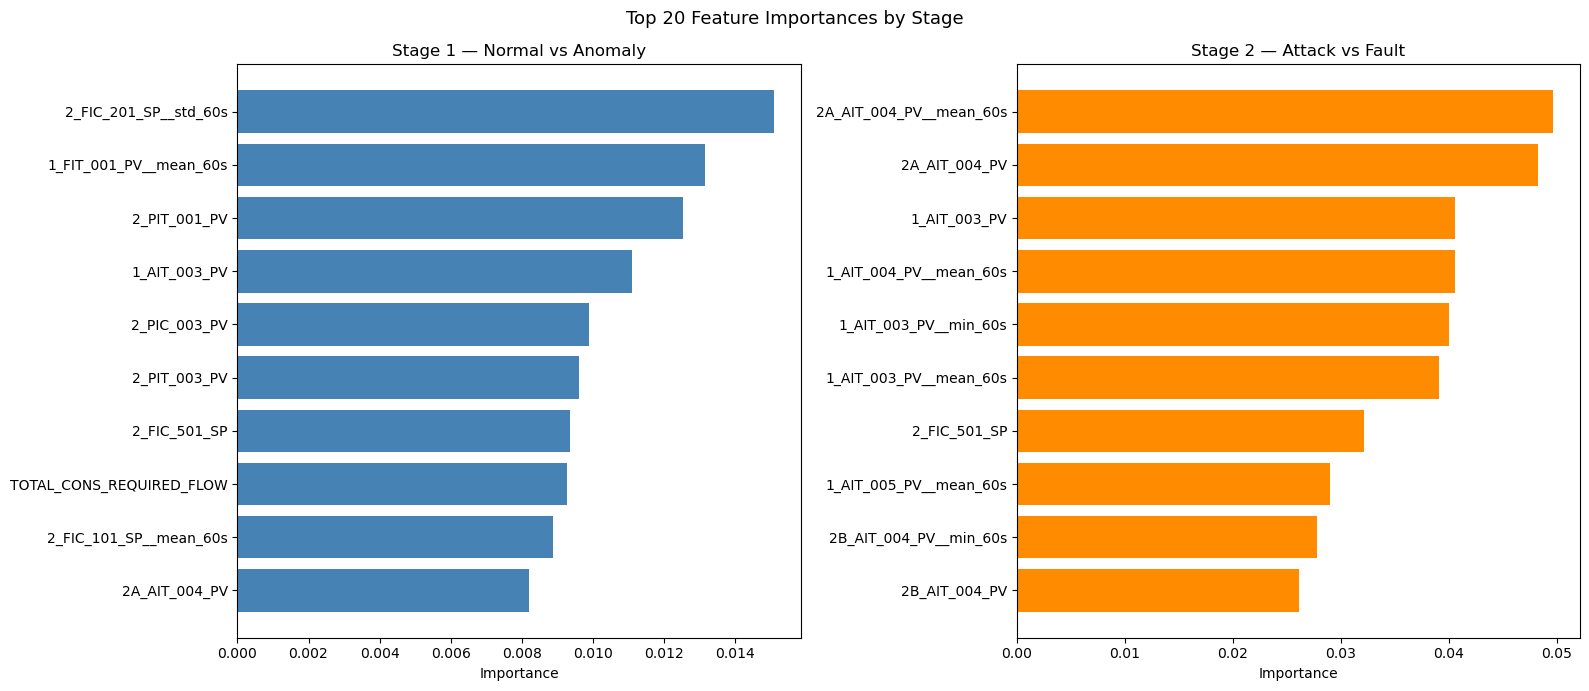

Saved: work/wadi_A2/results/nb7/proposal_feature_importance_20260330_152056_utc.png


In [21]:
# Top 20 for each stage independently
imp_s1 = rf_stage1.feature_importances_
imp_s2 = rf_s2.feature_importances_

idx_s1 = np.argsort(imp_s1)[::-1][:10]
idx_s2 = np.argsort(imp_s2)[::-1][:10]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,7))

# Stage 1
ax1.barh(
    [FEATURE_COLS[i] for i in idx_s1[::-1]],
    imp_s1[idx_s1[::-1]],
    color="steelblue"
)
ax1.set_xlabel("Importance")
ax1.set_title("Stage 1 — Normal vs Anomaly")

# Stage 2
ax2.barh(
    [FEATURE_COLS[i] for i in idx_s2[::-1]],
    imp_s2[idx_s2[::-1]],
    color="darkorange"
)
ax2.set_xlabel("Importance")
ax2.set_title("Stage 2 — Attack vs Fault")

fig.suptitle("Top 20 Feature Importances by Stage", fontsize=13)
plt.tight_layout()

feat_path = RESULTS_DIR / f"proposal_feature_importance_{RUN_ID}.png"
plt.savefig(feat_path, dpi=150)
plt.show()
print(f"Saved: {feat_path}")

#### Analysis
The two panels contrast which features each stage relies on to make its decision.  

**Stage 1 (Normal vs Anomaly)** is trained to detect any deviation from normal operation, so temporal features such as rolling standard deviations dominate. Attacks and faults both produce unusual variance. 

**Stage 2 (Attack vs Fault)** operates only on rows already flagged as anomalous and must distinguish between two abnormal states. Raw sensor process values dominate, suggesting the absolute magnitude of sensor readings at the time of the anomaly carries the discriminating signal.   

This divergence in feature reliance across stages supports the cascade architecture: the two classification problems are fundamentally different and benefit from separate models trained on different feature signals.

### ROC Curves (One-vs-Rest)
The ROC curves show the trade-off between true positive and false positive rates for each class as the classification threshold varies. A one-vs-rest strategy is used. Each class is evaluated against all others combined. 

Probabilities are derived from the full cascade. Stage 1 provides P(anomaly) and Stage 2 provides the conditional split between attack and fault. A classifier with no skill follows the diagonal; curves pushed toward the top-left corner indicate strong discrimination. The area under the curve (AUC) summarizes performance in a single number, where 1.0 is perfect.  

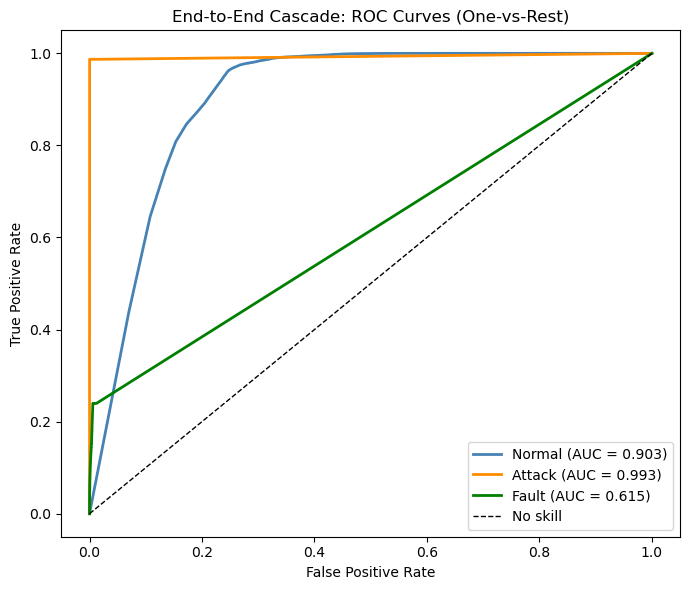

Saved: work/wadi_A2/results/nb7/proposal_roc_20260330_152056_utc.png


In [23]:
# Stage 2 probabilities on flagged rows only
s2_proba = rf_s2.predict_proba(flagged[FEATURE_COLS].values)
flagged["p_attack"] = s2_proba[:, 0]
flagged["p_fault"]  = s2_proba[:, 1]

# Merge back onto test_full
test_full["p_attack"] = flagged["p_attack"]
test_full["p_fault"]  = flagged["p_fault"]

# Fill NaN for rows Stage 2 never saw
test_full["p_attack"] = test_full["p_attack"].fillna(0.0)
test_full["p_fault"]  = test_full["p_fault"].fillna(0.0)

# Combine into cascade probabilities
test_full["prob_normal"] = 1 - test_full["s1_prob"]
test_full["prob_attack"] = test_full["s1_prob"] * test_full["p_attack"]
test_full["prob_fault"]  = test_full["s1_prob"] * test_full["p_fault"]

# Build y_true and probability matrix
y_true = test_full["label"].values
prob_matrix = test_full[["prob_normal", "prob_attack", "prob_fault"]].values

# Plot one ROC curve per class
fig, ax = plt.subplots(figsize=(7, 6))

class_labels = [0, 1, 2]
class_names  = ["Normal", "Attack", "Fault"]
colors       = ["steelblue", "darkorange", "green"]

for cls, name, color in zip(class_labels, class_names, colors):
    y_bin = (y_true == cls).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, prob_matrix[:, cls])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="No skill")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("End-to-End Cascade: ROC Curves (One-vs-Rest)")
ax.legend(loc="lower right")
plt.tight_layout()

roc_path = RESULTS_DIR / f"proposal_roc_{RUN_ID}.png"
plt.savefig(roc_path, dpi=150)
plt.show()
print(f"Saved: {roc_path}")

#### Analysis
The ROC curves show end-to-end cascade discrimination for each class using a one-vs-rest strategy.  

* **Attack** achieves an AUC of 0.993, confirming that the cascade assigns high probability scores to attack rows across nearly all threshold settings.
* **Normal** achieves 0.903, reflecting strong but imperfect separation from the anomaly classes.
* **Fault** achieves only 0.615, barely above the no-skill diagonal of 0.5.

This result is consistent with the 23.5% end-to-end fault recall observed in the confusion matrix. Stage 1 assigns low anomaly probability to most fault rows, so the cascade never accumulates enough probability mass on the fault class to discriminate it reliably. The fault AUC is not a failure of Stage 2 in isolation; it is a direct consequence of Stage 1 fault recall being the bottleneck in the cascade.

### Precision-Recall Curves (One-vs-Rest)
Precision-recall curves are particularly informative for imbalanced datasets. The test split contains 165k normal rows against roughly 2k each of attack and fault, meaning a classifier that predicts normal for everything would achieve high accuracy but zero recall on the minority classes.

The area under the precision-recall curve (AP) summarizes performance across all thresholds, where a score of 1.0 is perfect and a naive baseline equals the class prevalence. 

Strong attack performance is expected given the ROC results, while the fault curve is anticipated to reveal the cascade bottleneck more starkly than the ROC curves did.

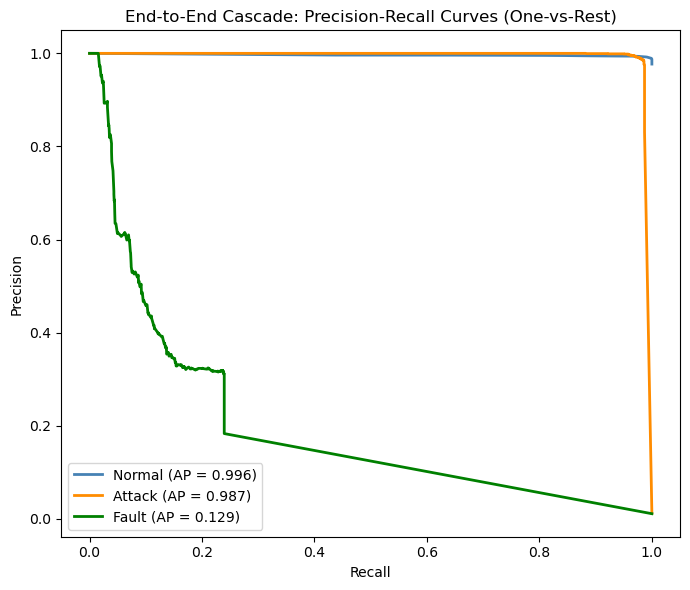

Saved: work/wadi_A2/results/nb7/proposal_pr_20260330_152056_utc.png


PosixPath('work/wadi_A2/results/nb7/proposal_pr_final.png')

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))

class_labels = [0, 1, 2]
class_names  = ["Normal", "Attack", "Fault"]
colors        = ["steelblue", "darkorange", "green"]

for cls, name, color in zip(class_labels, class_names, colors):
    y_bin = (y_true == cls).astype(int)
    precision, recall, _ = precision_recall_curve(y_bin, prob_matrix[:, cls])
    ap = average_precision_score(y_bin, prob_matrix[:, cls])
    ax.plot(recall, precision, color=color, lw=2,
            label=f"{name} (AP = {ap:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("End-to-End Cascade: Precision-Recall Curves (One-vs-Rest)")
ax.legend(loc="lower left")
plt.tight_layout()

pr_path = RESULTS_DIR / f"proposal_pr_{RUN_ID}.png"
plt.savefig(pr_path, dpi=150)
plt.show()
print(f"Saved: {pr_path}")

shutil.copy(
    RESULTS_DIR / f"proposal_pr_{RUN_ID}.png",
    RESULTS_DIR / "proposal_pr_final.png"
)

 #### Analysis
 The precision-recall curves reveal the cascade bottleneck more starkly than the ROC curves.  
 Normal and attack both achieve near-perfect average precision (0.996 and 0.987 respectively), with precision remaining close to 1.0 across all recall levels. The fault classes achieves an average precision of only 0.129. This is because Stage 1 assigns low anomaly probability to most fault rows, the cascade accumulates insufficient probability mass on the fault class to achieve reliable precision at any recall level.

Lowering the detection threshold to recover more fault rows inevitably draws in a disproportionate number of normal rows. This result, combined with the confusion matrix and ROC curves, consistently points to Stage 1 fault recall as the single most important target for improving end-to-end pipeline performance.

# Stage 8 - Reflection  
Documents key decisions, assumptions, and results from this notebook.

In [19]:
reflection = [
    ("Task definition",
     "Stage 2 of the cascaded anomaly classification system. Given a row "
     "flagged as anomaly by Stage 1, classify it as cyber attack (1) or "
     "injected sensor fault (2). This is the novel contribution of the "
     "three-class pipeline, prior WaDi literature treats anomaly detection "
     "as binary and does not attempt to distinguish attack from fault."),

    ("Training data",
     f"Train split: {len(X_train):,} rows — {(y_train==1).sum():,} attack, "
     f"{(y_train==2).sum():,} fault. Near 1:1 class balance achieved by "
     "increasing TARGET_FAULT_PCT in NB3. No class weighting required. "
     "Normal rows excluded — Stage 2 operates only on confirmed anomalies."),

    ("Clean evaluation results",
     f"OOB score: {rf_s2.oob_score_:.4f}. Test accuracy: 99.28% on "
     f"{len(X_test):,} confirmed anomaly rows. "
     f"Attack precision=0.9910, recall=0.9950. "
     f"Fault precision=0.9948, recall=0.9906. "
     f"Only 28 misclassifications: {int(attack_as_fault)} attacks called fault, "
     f"{int(fault_as_attack)} faults called attack."),

    ("Cascade evaluation results",
     f"End-to-end performance at Stage 1 threshold=0.4: "
     f"attacks correctly classified {attacks_correct:,}/{n_attack:,} ({attacks_correct/n_attack*100:.1f}%), "
     f"faults correctly classified {faults_correct:,}/{n_fault:,} ({faults_correct/n_fault*100:.1f}%), "
     f"normal rows falsely flagged {fp_reaching_s2:,}/{n_normal:,} ({fp_reaching_s2/n_normal*100:.1f}%). "
     "The gap between clean and cascade fault performance is entirely attributable "
     "to Stage 1 fault recall, Stage 2 correctly classifies faults that reach it."),

    ("Feature importance",
     "Rolling features dominate Stage 2 importances (13 of top 20), contrasting "
     "with NB6 where raw sensor readings dominated. Attack vs fault discrimination "
     "relies on temporal statistics — drift, sustained shifts, and variance changes "
     "— rather than instantaneous sensor values. Top sensors: 2A_AIT_004_PV, "
     "1_AIT_003_PV, 1_AIT_004_PV. Importances are less flat than NB6 (top "
     "feature 0.050 vs 0.017), indicating attack and fault signatures are "
     "concentrated in specific sensors."),

    ("Known limitations",
     "Fault detection at Stage 1 is the primary bottleneck, only 24% of faults "
     "are flagged as anomalies and reach Stage 2. This reflects the challenge of "
     "detecting synthetic faults injected into normal rows using a supervised "
     "binary classifier trained predominantly on attack signatures. "
     "Revisiting fault injection strategy and exploring unsupervised Stage 1 "
     "detectors are natural directions for future work."),

    ("Next step",
     "Paper writing. Key results to report: (1) binary RF baseline (NB6), "
     "(2) Stage 2 clean evaluation — 99.28% attack vs fault accuracy, "
     "(3) end-to-end cascade — 98.6% attack accuracy, 23.5% fault accuracy, "
     "0.6% false positive rate on normal rows."),
]

print("Pipeline Reflection")
print("=" * 60)
for title, content in reflection:
    print(f"\n[{title}]")
    print(f"  {content}")

Pipeline Reflection

[Task definition]
  Stage 2 of the cascaded anomaly classification system. Given a row flagged as anomaly by Stage 1, classify it as cyber attack (1) or injected sensor fault (2). This is the novel contribution of the three-class pipeline, prior WaDi literature treats anomaly detection as binary and does not attempt to distinguish attack from fault.

[Training data]
  Train split: 16,633 rows — 7,986 attack, 8,647 fault. Near 1:1 class balance achieved by increasing TARGET_FAULT_PCT in NB3. No class weighting required. Normal rows excluded — Stage 2 operates only on confirmed anomalies.

[Clean evaluation results]
  OOB score: 0.9975. Test accuracy: 99.28% on 3,907 confirmed anomaly rows. Attack precision=0.9910, recall=0.9950. Fault precision=0.9948, recall=0.9906. Only 28 misclassifications: 10 attacks called fault, 18 faults called attack.

[Cascade evaluation results]
  End-to-end performance at Stage 1 threshold=0.4: attacks correctly classified 1,963/1,991 (9